#### Scenario 2: The "Blob" of Data (Skewed Variables)

  * **Goal:** You are analyzing a housing dataset. You want to understand the relationship between "median income" (in tens of thousands) and "median house value".

  * **Minimal Starter Dataset:** This data is right-skewed, just like real financial data. Most people have low-to-medium income, but a few have very high income.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from helpers.plot_seaborn import plot_seaborn

In [3]:
# Synthetic Data (log-normally distributed)
np.random.seed(42)
N_SAMPLES = 500
income = np.random.lognormal(mean=3.0, sigma=0.8, size=N_SAMPLES)
# House value is a function of income + some noise
house_value = (income * 50_000) + np.random.normal(0, 25_000, size=N_SAMPLES)
# Clamp values to be realistic
income = np.clip(income, 1, 50)
house_value = np.clip(house_value, 20_000, 500_000)

# Let's say population is somewhat correlated with income
population = (income * 1000) + np.random.randint(-500, 500, size=N_SAMPLES)
population = np.clip(population, 500, 50000)  # Ensure it's positive


data_scenario_2 = pd.DataFrame({
	"median_income_10k": income,
	"median_house_value": house_value,
	"population": population,
})

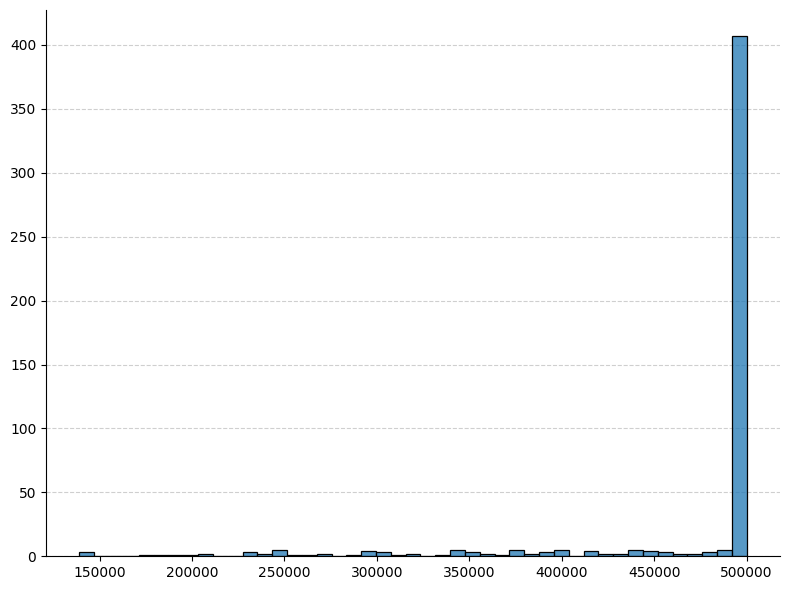

In [4]:
plot_seaborn(
	df=data_scenario_2,
	x="median_house_value",
	plot_type="histplot",
	figsize=(8, 6),
	despine=True,
)

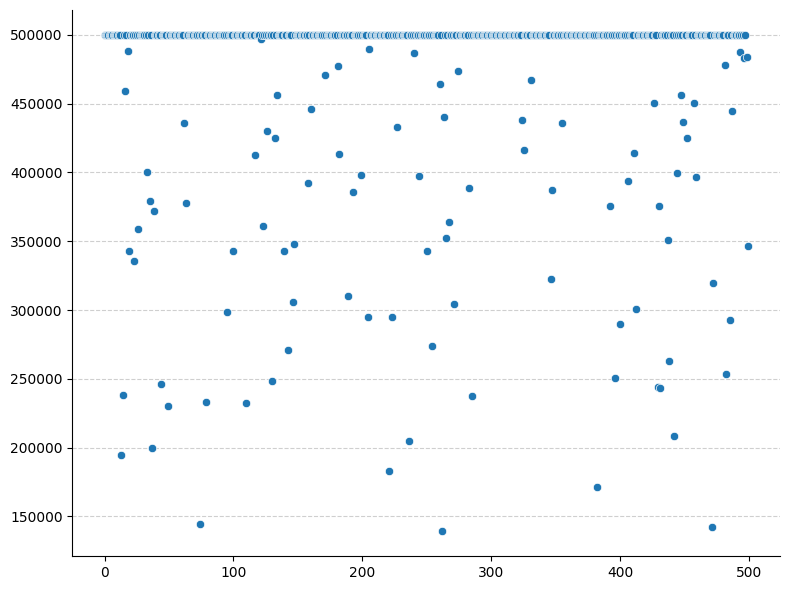

In [5]:
plot_seaborn(
	df=data_scenario_2["median_house_value"],
	plot_type="scatterplot",
	figsize=(8, 6),
	despine=True,
)

  * **The Task:** The standard scatter plot is "blobbed" into the bottom-left corner, hiding the true relationship. Design and implement a visualization that *reveals* the underlying pattern. (Hint: How do statisticians handle skewed distributions?).

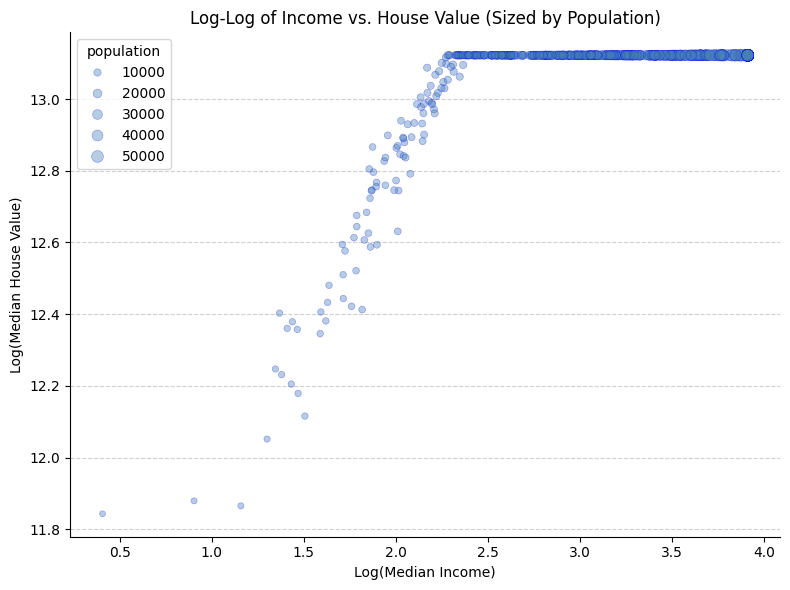

In [6]:
# Apply the log transforms
data_scenario_2["log_income"] = np.log(data_scenario_2["median_income_10k"])
data_scenario_2["log_value"] = np.log(data_scenario_2["median_house_value"])

plot_seaborn(
	df=data_scenario_2,
	x="log_income",
	y="log_value",
	plot_type="scatterplot",
	title="Log-Log of Income vs. House Value (Sized by Population)",
	xlabel="Log(Median Income)",
	ylabel="Log(Median House Value)",
	figsize=(8, 6),
	color="steelblue",
	edgecolor="blue",
	size="population",
	alpha=0.4,
)


##### The Tobit Model – Definition and Assumptions

##### Latent Mean (Predicted True Value)
$$
\mu_i = \beta_0 + \beta_1 x_i
$$
- $\mu_i$: Latent mean for observation $i$
- $\beta_0$: Intercept parameter
- $\beta_1$: Slope parameter
- $x_i$: Predictor value (e.g., income) for observation $i$

Vectorized form:
$$
\boldsymbol{\mu} = \mathbf{X} \boldsymbol{\beta}
$$
- $\boldsymbol{\mu}$: Vector of latent means for all observations
- $\mathbf{X}$: Design matrix (n × 2, with column of 1s and predictors)
- $\boldsymbol{\beta}$: Parameter vector $[\beta_0, \beta_1]$

##### Normal Log-PDF (for Uncensored Points)
$$
\log \left( \frac{1}{\sigma} \phi\left( \frac{y_i - \mu_i}{\sigma} \right) \right) = -\log(\sigma) + \log \phi(z_i)
$$
Where:
$$
\phi(z) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{z^2}{2} \right), \quad z_i = \frac{y_i - \mu_i}{\sigma}
$$
Expanded:
$$
- \log(\sigma) - 0.5 \log(2\pi) - 0.5 \left( \frac{y_i - \mu_i}{\sigma} \right)^2
$$
- $\sigma$: Standard deviation of errors
- $\phi(z)$: Standard normal PDF at $z$
- $y_i$: Observed value for observation $i$
- $z_i$: Standardized residual

##### Log-Survival Function (for Censored Points)
$$
\log \left( 1 - \Phi\left( \frac{c - \mu_i}{\sigma} \right) \right) = \log \left( SF(z_i) \right)
$$
Where:
$$
z_i = \frac{c - \mu_i}{\sigma}, \quad \Phi(z) = 0.5 + 0.5 \cdot \operatorname{erf}\left( \frac{z}{\sqrt{2}} \right), \quad SF(z) = 0.5 \cdot \operatorname{erfc}\left( \frac{z}{\sqrt{2}} \right)
$$
- $c$: Censoring threshold (e.g., upper cap)
- $\Phi(z)$: Standard normal CDF at $z$
- $SF(z)$: Standard normal survival function (1 - CDF) at $z$
- $\operatorname{erf}$: Error function
- $\operatorname{erfc}$: Complementary error function (1 - erf)

##### Full Log-Likelihood

$$
\ell(\theta) = \sum_{i \in \text{uncens}} \left[ -\log(\sigma) + \log \phi\left( \frac{y_i - \mu_i}{\sigma} \right) \right] + \sum_{i \in \text{cens}} \log \left( 1 - \Phi\left( \frac{c - \mu_i}{\sigma} \right) \right)
$$
Negative log-likelihood (for minimization):
$$
-\ell(\theta)
$$
- $\theta$: Parameter set $(\beta_0, \beta_1, \sigma)$
- $\text{uncens}$: Set of uncensored observations
- $\text{cens}$: Set of censored observations

In [7]:
from scipy.stats import norm


def tobit_neg_log_lik(
	params: np.ndarray,
	X: np.ndarray,
	y: np.ndarray,
	upper: float,
) -> float:
	"""
	Compute the negative log-likelihood for the Tobit model with right-censoring.

	The Tobit model is used for censored regression where the dependent variable
	is censored at an upper limit. This function calculates the negative log-likelihood
	for maximum likelihood estimation.

	Parameters
	----------
	params : np.ndarray
		Model parameters. The last element is sigma (standard deviation of the error term),
		and the preceding elements are the beta coefficients (including intercept).
	X : np.ndarray, shape (n_samples, n_features)
		Design matrix (independent variables), including a column of ones for the intercept.
	y : np.ndarray, shape (n_samples,)
		Observed dependent variable values, with censored values set to the upper limit.
	upper : float
		The upper censoring threshold for the dependent variable.

	Returns
	-------
	float
		The negative log-likelihood value. Returns np.inf if sigma <= 0.

	Notes
	-----
	The Tobit model assumes that the latent variable y* = X @ beta + epsilon,
	where epsilon ~ N(0, sigma^2), and y = min(y*, upper) for right-censoring.

	The log-likelihood is computed as:
	- For uncensored observations: log(pdf of (y - mu) / sigma)
	- For censored observations: log(SF of (upper - mu) / sigma)
	- Minus the normalization term for sigma.

	Examples
	--------
	>>> import numpy as np
	>>> # Example data
	>>> X = np.array([[1, 1], [1, 2], [1, 3]])
	>>> y = np.array([2.0, 3.5, 5.0])
	>>> params = np.array([1.0, 0.5, 0.1])  # beta0, beta1, sigma
	>>> upper = 5.0
	>>> nll = tobit_neg_log_lik(params, X, y, upper)
	>>> print(f"Negative log-likelihood: {nll:.3f}")
	Negative log-likelihood: ...

	"""
	beta = params[:-1]
	sigma = params[-1]
	if sigma <= 0:
		return np.inf
	mu = X @ beta
	cens = y == upper
	uncens = ~cens

	lik_uncens = norm.logpdf((y[uncens] - mu[uncens]) / sigma)
	lik_cens = norm.logsf((upper - mu[cens]) / sigma)

	num_uncens = np.sum(uncens)
	loglik = np.sum(lik_uncens) + np.sum(lik_cens) - num_uncens * np.log(sigma)
	return -loglik


In [8]:
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

# Define censoring thresholds for the Tobit model
# Lower and upper bounds where data is censored (clipped)
lower = 20000
upper = 500000

# Identify which observations are right-censored (hit the upper limit)
# Right-censored: true value is >= upper but we only observe upper
right_cens = data_scenario_2["median_house_value"] == upper
# Uncensored: observations that are not at the upper limit
uncens = ~right_cens

# Prepare design matrix X with intercept column (ones) and predictor variable
# X shape: (n_samples, 2) where first column is 1 for intercept
X = np.c_[np.ones(len(data_scenario_2)), data_scenario_2["median_income_10k"]]
# Extract response variable as numpy array
y = data_scenario_2["median_house_value"].values

# Get initial parameter guess using linear regression on uncensored data only
# This provides a reasonable starting point for Tobit optimization
X_unc = data_scenario_2.loc[uncens, "median_income_10k"].values.reshape(-1, 1)
y_unc = data_scenario_2.loc[uncens, "median_house_value"]

# Fit linear model to uncensored data to get initial beta estimates
lin_model = LinearRegression().fit(X_unc, y_unc)
# Extract intercept and slope coefficients
init_beta = np.array([lin_model.intercept_, lin_model.coef_[0]])
# Estimate sigma from residuals of linear model
init_sigma = np.std(y_unc - lin_model.predict(X_unc))
# Combine parameters: [beta0, beta1, sigma]
init_params = np.r_[init_beta, init_sigma]

# Optimize Tobit model using Nelder-Mead method
# Minimize negative log-likelihood to find maximum likelihood estimates
result = minimize(
	tobit_neg_log_lik, init_params, args=(X, y, upper), method="Nelder-Mead"
)
# Extract optimized parameters from result
tobit_params = result.x
# Unpack parameters: intercept, slope, and error standard deviation
tobit_intercept, tobit_slope, tobit_sigma = tobit_params

# Bootstrap confidence intervals to quantify parameter uncertainty
# Resample data with replacement to estimate sampling distribution
n_bootstraps = 1000
bootstrap_params = []

for i in range(n_bootstraps):
	# Sample indices with replacement (bootstrap sample)
	indices = np.random.choice(len(X), size=len(X), replace=True)
	X_boot = X[indices]
	y_boot = y[indices]

	try:
		# Fit Tobit model on bootstrap sample
		boot_result = minimize(
			tobit_neg_log_lik,
			tobit_params,
			args=(X_boot, y_boot, upper),
			method="Nelder-Mead",
		)
		# Only keep successful optimizations
		if boot_result.success:
			bootstrap_params.append(boot_result.x)
	except:
		continue

bootstrap_params = np.array(bootstrap_params)

# Calculate 95% confidence intervals from bootstrap distribution
# Percentile method: use 2.5th and 97.5th percentiles
alpha = 0.05
lower_percentile = 100 * alpha / 2
upper_percentile = 100 * (1 - alpha / 2)

# Confidence interval for intercept parameter
ci_intercept = np.percentile(
	bootstrap_params[:, 0], [lower_percentile, upper_percentile]
)
# Confidence interval for slope parameter
ci_slope = np.percentile(bootstrap_params[:, 1], [lower_percentile, upper_percentile])

# Generate predictions over full income range using Tobit estimates
# Create evenly spaced values across the observed income range
x_range = np.linspace(
	data_scenario_2["median_income_10k"].min(),
	data_scenario_2["median_income_10k"].max(),
	100,
)
# Predicted latent mean: y = intercept + slope * x
y_pred = tobit_intercept + tobit_slope * x_range

# Generate bootstrap predictions for confidence band around regression line
# Use first 100 bootstrap samples for computational efficiency
bootstrap_preds = []
for params in bootstrap_params[:100]:
	bootstrap_preds.append(params[0] + params[1] * x_range)

bootstrap_preds = np.array(bootstrap_preds)
# Calculate confidence bands from bootstrap predictions
y_pred_lower = np.percentile(bootstrap_preds, lower_percentile, axis=0)
y_pred_upper = np.percentile(bootstrap_preds, upper_percentile, axis=0)

# Print parameter estimates with confidence intervals
print(f"Tobit Intercept: {tobit_intercept:.2f}")
print(f"95% CI for Intercept: [{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]")
print(f"Tobit Slope: {tobit_slope:.2f}")
print(f"95% CI for Slope: [{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]")

Tobit Intercept: 11690.70
95% CI for Intercept: [-8539.52, 30268.23]
Tobit Slope: 48563.36
95% CI for Slope: [46277.82, 51101.91]


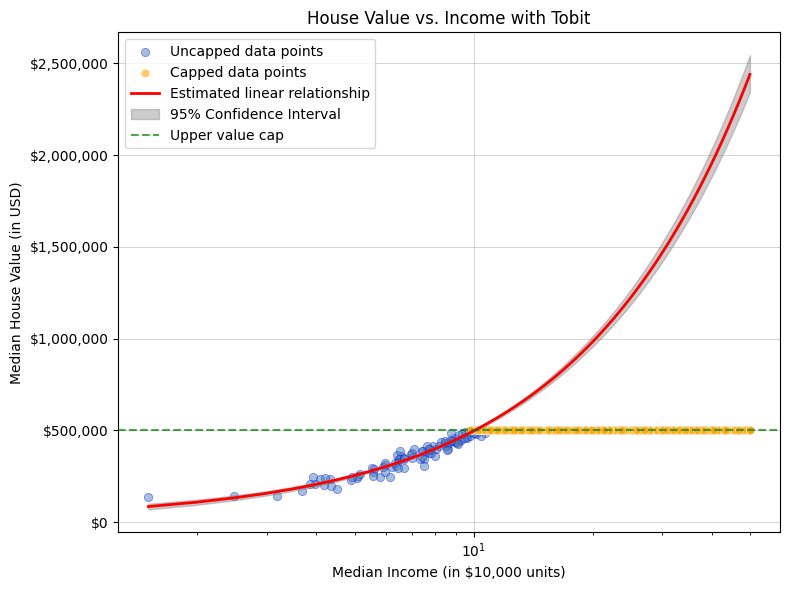

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot uncensored points using seaborn
sns.scatterplot(
	data=data_scenario_2[uncens],
	x="median_income_10k",
	y="median_house_value",
	alpha=0.5,
	color="steelblue",
	edgecolor="blue",
	label="Uncapped data points",
	ax=ax,
)

# Plot censored points using seaborn
sns.scatterplot(
	data=data_scenario_2[right_cens],
	x="median_income_10k",
	y="median_house_value",
	alpha=0.6,
	color="orange",
	label="Capped data points",
	ax=ax,
)

# Overlay the Tobit-estimated line
ax.plot(
	x_range,
	y_pred,
	color="red",
	linewidth=2,
	label="Estimated linear relationship",
)

# Add confidence band
ax.fill_between(
	x_range,
	y_pred_lower,
	y_pred_upper,
	color="gray",
	alpha=0.4,
	label="95% Confidence Interval",
)

# Add cap line for context
ax.axhline(upper, color="green", linestyle="--", alpha=0.7, label="Upper value cap")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))

# Set scales and labels with units
ax.set_xscale("log")  # Spreads out the low-income blob
ax.set_xlabel("Median Income (in $10,000 units)")
ax.set_ylabel("Median House Value (in USD)")
ax.set_title("House Value vs. Income with Tobit")
ax.grid(True, alpha=0.6, linewidth=0.4, color="grey")
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()